In [36]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Sample documents
documents = [
    "I love reading about machine learning and artificial intelligence.",
    "Artificial intelligence is a fascinating field.",
    "I enjoy programming in Python.",
    "Python is great for data science and machine learning.",
    "Data science involves statistics and machine learning.",
    "The applications of AI are vast and varied.",
    "Learning data science can be fun and rewarding."
]

# Create a TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(documents)   # Documents-words matrix
tfidf.toarray().shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(7, 22)

In [37]:
feature_names = vectorizer.get_feature_names_out()   # extracted words
print(feature_names)

['ai' 'applications' 'artificial' 'data' 'enjoy' 'fascinating' 'field'
 'fun' 'great' 'intelligence' 'involves' 'learning' 'love' 'machine'
 'programming' 'python' 'reading' 'rewarding' 'science' 'statistics'
 'varied' 'vast']


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [39]:
tfidf.toarray()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array([[0.        , 0.        , 0.40213084, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.40213084,
        0.        , 0.29842743, 0.48444486, 0.34372811, 0.        ,
        0.        , 0.48444486, 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.45163515, 0.        , 0.        ,
        0.54408243, 0.54408243, 0.        , 0.        , 0.45163515,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.60981929,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.60981929,
        0.50620239, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.37505999, 0.        ,
        0.       

In [41]:
# Number of topics
n_topics = 2
# NMF Model
X = tfidf.toarray()
nmf = NMF(n_components=n_topics, random_state=42)
W_nmf = nmf.fit_transform(X)  # Document-topic matrix for NMF. Basis matrix
H_nmf = nmf.components_  # Topic-word matrix for NMF. Coeffecient matrix
print(W_nmf.shape, H_nmf.shape)


(7, 2) (2, 22)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [42]:
# Print NMF Topics
print("NMF Topics:")
for topic_idx, topic in enumerate(H_nmf):
    print(f"Topic {topic_idx + 1}:")
    top_words_indices = topic.argsort()[-5:][::-1]  # Get top 5 word, using [-5:],indices in descending order using [::-1]
    # Initialize an empty list to hold top words
    top_words = []
        # Use a normal loop to get the top words
    for i in top_words_indices:
        top_words.append(feature_names[i])  # Append each word to the list

    print(", ".join(top_words))

NMF Topics:
Topic 1:
science, data, learning, machine, python
Topic 2:
artificial, intelligence, fascinating, field, reading


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# PCA Model
pca = PCA(n_components=n_topics)
W_pca = pca.fit_transform(tfidf.toarray())  # Document projection for PCA

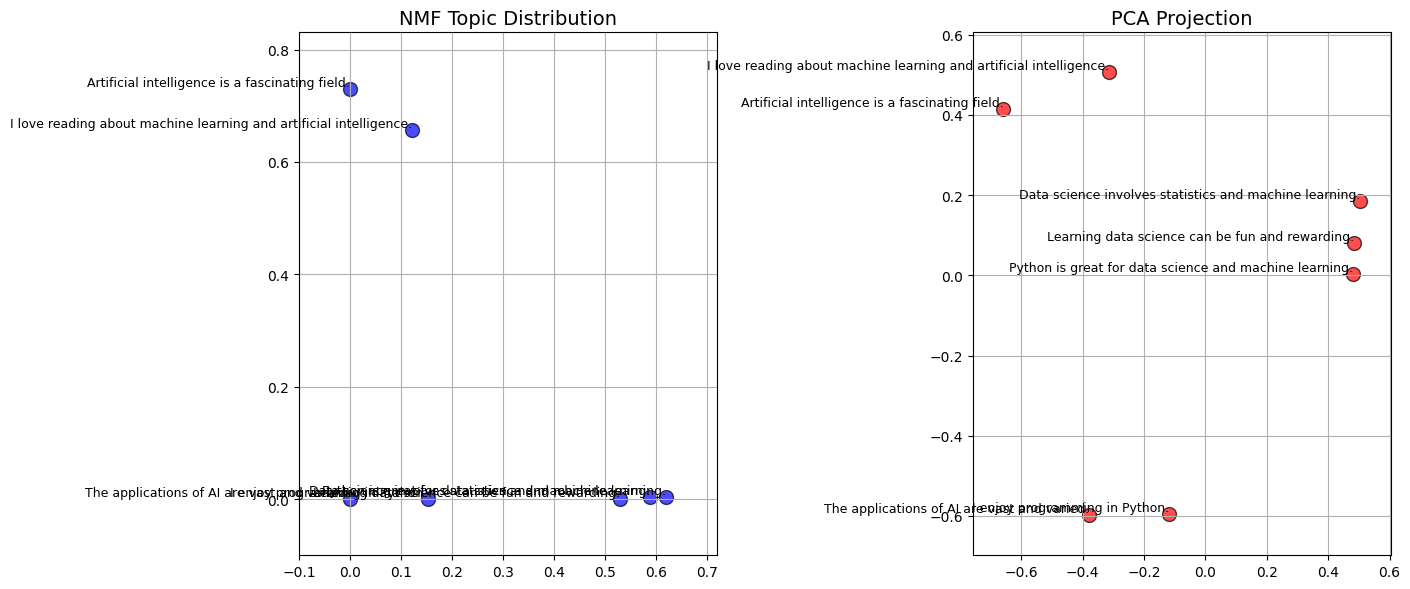

In [ ]:
# Plotting the results
plt.figure(figsize=(14, 6))

# NMF Results
plt.subplot(1, 2, 1)
plt.title("NMF Topic Distribution", fontsize=14)
plt.scatter(W_nmf[:, 0], W_nmf[:, 1], c='blue', s=100, alpha=0.7, edgecolor='k', marker='o')
for i, txt in enumerate(documents):
    plt.annotate(txt, (W_nmf[i, 0], W_nmf[i, 1]), fontsize=9, ha='right', va='bottom')
plt.grid(True)
plt.xlim(W_nmf[:, 0].min() - 0.1, W_nmf[:, 0].max() + 0.1)
plt.ylim(W_nmf[:, 1].min() - 0.1, W_nmf[:, 1].max() + 0.1)

# PCA Results
plt.subplot(1, 2, 2)
plt.title("PCA Projection", fontsize=14)
plt.scatter(W_pca[:, 0], W_pca[:, 1], c='red', s=100, alpha=0.7, edgecolor='k', marker='o')
for i, txt in enumerate(documents):
    plt.annotate(txt, (W_pca[i, 0], W_pca[i, 1]), fontsize=9, ha='right', va='bottom')
plt.grid(True)
plt.xlim(W_pca[:, 0].min() - 0.1, W_pca[:, 0].max() + 0.1)
plt.ylim(W_pca[:, 1].min() - 0.1, W_pca[:, 1].max() + 0.1)

plt.tight_layout()
plt.show()


### Naming the Topics
Based on the top words, you could name the topics as follows:

* **Topic 1**: Data Science and Machine Learning (since it includes words like "data," "science," "machine," and "learning").

* **Topic 2**: Python and Artificial Intelligence (since it includes words like "python," "love," "reading," and "artificial intelligence").

# Topic Modeling using LDA

In [ ]:
pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.2 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
import pyLDAvis.gensim_models
import pyLDAvis

# Download NLTK stopwords
nltk.download('punkt')
nltk.download('stopwords')

# Sample documents
documents = [
    "I love reading about machine learning and artificial intelligence.",
    "Artificial intelligence is a fascinating field.",
    "I enjoy programming in Python.",
    "Python is great for data science and machine learning.",
    "Data science involves statistics and machine learning.",
    "The applications of AI are vast and varied.",
    "Learning data science can be fun and rewarding."
]

# Preprocess the documents
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalpha() and word not in stop_words]

processed_docs = [preprocess(doc) for doc in documents]

# Create a dictionary and corpus
dictionary = corpora.Dictionary(processed_docs)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# Build the LDA model
num_topics = 2
lda_model = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=10)

# Print the topics discovered by LDA
print("LDA Topics:")
for idx, topic in lda_model.print_topics(num_topics=num_topics):
    print(f"Topic {idx + 1}: {topic}")

# Visualization
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


LDA Topics:
Topic 1: 0.111*"learning" + 0.109*"science" + 0.109*"data" + 0.079*"machine" + 0.047*"python" + 0.047*"involves" + 0.047*"statistics" + 0.047*"rewarding" + 0.047*"fun" + 0.047*"great"
Topic 2: 0.104*"intelligence" + 0.104*"artificial" + 0.063*"python" + 0.062*"fascinating" + 0.062*"field" + 0.062*"reading" + 0.062*"love" + 0.062*"programming" + 0.062*"enjoy" + 0.062*"machine"
